In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Derivation of the Crank–Nicolson Method

This notebook cell outlines a step-by-step derivation of the Crank–Nicolson scheme for the 1D heat equation:

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, 
\quad 0 < x < L, \quad t > 0.
$$

---

## 1. The Heat Equation

We consider the one-dimensional heat (diffusion) equation on \([0, L]\). We partition the spatial domain into \(N\) intervals of width 
$\Delta x = \tfrac{L}{N}$, so 
$$
x_i = i\,\Delta x, \quad i = 0,1,\dots,N.
$$
We partition the time domain into steps of size $\Delta t$, so 
$$
t^n = n\,\Delta t, \quad n = 0,1,2,\dots.
$$
We denote
$$
u_i^n \approx u(x_i, t^n).
$$

---

## 2. Discretize the Time Derivative

Approximate the time derivative by a forward difference:

$$
\frac{\partial u}{\partial t}(x_i, t^n) \;\approx\; \frac{u_i^{n+1} - u_i^n}{\Delta t}.
$$

---

## 3. Discretize the Space Derivative

Approximate the second spatial derivative by a central difference:

$$\frac{\partial^2 u}{\partial x^2}(x_i, t^n) 
\approx
\frac{u_{i+1}^n - 2\,u_i^n + u_{i-1}^n}{(\Delta x)^2}.$$

---

## 4. Crank–Nicolson: Averaging Explicit and Implicit (recall midpoint)

Crank–Nicolson is formed by **averaging** the spatial derivatives at time $n$ (explicit) and $n+1$ (implicit). So,

$$
\frac{u_i^{n+1} - u_i^n}{\Delta t}
=
\frac{\alpha}{2}
\Bigl[
  \frac{u_{i+1}^n - 2 u_i^n + u_{i-1}^n}{(\Delta x)^2}
  \;+\;
  \frac{u_{i+1}^{n+1} - 2 u_i^{n+1} + u_{i-1}^{n+1}}{(\Delta x)^2}
\Bigr].
$$

---

## 5. Introduce the Mesh Ratio

Define the mesh ratio

$$
r \;=\; \frac{\alpha \,\Delta t}{(\Delta x)^2}.
$$

Multiply both sides of the Crank–Nicolson equation by $\Delta t$ and collect like terms:

$$
u_i^{n+1} - u_i^n
=
\frac{r}{2}
\Bigl[
  (u_{i+1}^n - 2\,u_i^n + u_{i-1}^n)
  +
  (u_{i+1}^{n+1} - 2\,u_i^{n+1} + u_{i-1}^{n+1})
\Bigr].
$$

After rearranging, we get:

$$
-\frac{r}{2}\,u_{i-1}^{n+1} 
\;+\;
\bigl(1 + r\bigr)\,u_i^{n+1}
\;-\;
\frac{r}{2}\,u_{i+1}^{n+1}
=
\frac{r}{2}\,u_{i-1}^n
\;+\;
\bigl(1 - r\bigr)\,u_i^n
\;+\;
\frac{r}{2}\,u_{i+1}^n.
$$

---

## 6. Tridiagonal System Form

For $i = 1, 2, \ldots, N-1$, this defines a **tridiagonal linear system** in the unknowns $\{u_i^{n+1}\}$. Denote the left-hand side as $A \mathbf{u}^{n+1}$ and the right-hand side as $B \mathbf{u}^n$. We can solve it at each time step using the **Thomas algorithm**:

$$
A\,\mathbf{u}^{n+1} = B\,\mathbf{u}^{n}.
$$

---

## 7. Final Scheme

Hence, the Crank–Nicolson scheme for the 1D heat equation is:

$$
-\frac{r}{2}\,u_{i-1}^{n+1}
\;+\;
(1 + r)\,u_i^{n+1}
\;-\;
\frac{r}{2}\,u_{i+1}^{n+1}
\;=\;
\frac{r}{2}\,u_{i-1}^n
\;+\;
(1 - r)\,u_i^n
\;+\;
\frac{r}{2}\,u_{i+1}^n,
$$
subject to your chosen boundary conditions (Dirichlet, Neumann, etc.) at $i = 0$ and $i = N$.

## Matrix Form

We can write this entire system for $i = 1, 2, \dots, N-1$ in **matrix form** as:

$$
A \,\mathbf{u}^{n+1}
\;=\;
B \,\mathbf{u}^{n},
$$

where 
$\mathbf{u}^n$ is the vector 
$\bigl[u_1^n,\; u_2^n,\;\dots,\;u_{N-1}^n\bigr]^T$,  
and \(A\) and \(B\) are **tridiagonal** matrices of size $(N-1)\times(N-1)$.

### The Matrix \(A\)

$$
A = 
\begin{bmatrix}
1 + r & -\tfrac{r}{2} & 0 & \cdots & 0 \\
-\tfrac{r}{2} & 1 + r & -\tfrac{r}{2} & \ddots & \vdots \\
0 & -\tfrac{r}{2} & 1 + r & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -\tfrac{r}{2} \\
0 & \cdots & 0 & -\tfrac{r}{2} & 1 + r
\end{bmatrix}.
$$

### The Matrix \(B\)

$$
B = 
\begin{bmatrix}
1 - r & \tfrac{r}{2} & 0 & \cdots & 0 \\
\tfrac{r}{2} & 1 - r & \tfrac{r}{2} & \ddots & \vdots \\
0 & \tfrac{r}{2} & 1 - r & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & \tfrac{r}{2} \\
0 & \cdots & 0 & \tfrac{r}{2} & 1 - r
\end{bmatrix}.
$$

Hence, the **Crank–Nicolson update** for each time step is:

$$
\mathbf{u}^{n+1} = A^{-1} B \,\mathbf{u}^{n},
$$

though in practice we do **not** invert \(A\) directly; rather, we solve the linear system 
$$
A \,\mathbf{u}^{n+1} = B \,\mathbf{u}^{n}
$$
efficiently using the **Thomas algorithm** (a specialized $O(N)$ elimination for tridiagonal matrices).

---


**Key points:**
- This is **second-order accurate** in both time and space.
- **Unconditionally stable** for linear diffusion problems.
- Solved via a tridiagonal linear system at each timestep.


# Thomas Algorithm: Step-by-Step Derivation

We want to solve a **tridiagonal linear system** of \\( n \\) equations:

$$
\begin{aligned}
b_1\,x_1 \;+\; c_1\,x_2 &= d_1, \\[6pt]
a_2\,x_1 \;+\; b_2\,x_2 \;+\; c_2\,x_3 &= d_2, \\[4pt]
a_3\,x_2 \;+\; b_3\,x_3 \;+\; c_3\,x_4 &= d_3, \\[-2pt]
&\;\;\;\;\vdots \\[-4pt]
a_n\,x_{n-1} \;+\; b_n\,x_n &= d_n.
\end{aligned}
$$

Here:
- \\( a_i \\) are the subdiagonal entries (\\( i = 2,\dots,n \\); often we take \\(a_1 = 0\\) by convention),
- \\( b_i \\) are the main diagonal entries (\\( i = 1,\dots,n \\)),
- \\( c_i \\) are the superdiagonal entries (\\( i = 1,\dots,n-1 \\); often \\(c_n=0\\) by convention),
- \\( d_i \\) are the constants on the right-hand side.

Our goal is to find \\( x_1, x_2,\dots,x_n \\) in \\( \mathcal{O}(n) \\) time. The procedure involves two phases:

1. **Forward Elimination** – to remove the subdiagonal \\( a_i \\).
2. **Back Substitution** – to solve the resulting upper-triangular system.

---

## 1. Forward Elimination

We sequentially eliminate \\( a_2, a_3, \dots, a_n \\) by modifying each row in turn. 

### Step 1 (Row 1)

The first equation is

$$
b_1 \, x_1 \;+\; c_1 \, x_2 \;=\; d_1.
$$

We **normalize** this row by dividing through by \\( b_1 \\) (assuming \\( b_1 \neq 0 \\)):

$$
x_1 \;+\; \frac{c_1}{b_1}\,x_2 \;=\; \frac{d_1}{b_1}.
$$

Define the **modified** superdiagonal and right-hand side for row 1:

$$
c'_1 \;=\; \frac{c_1}{b_1}, 
\quad
d'_1 \;=\; \frac{d_1}{b_1}.
$$

Hence the first row (in **modified** form) is:

$$
x_1 \;+\; c'_1 \, x_2 \;=\; d'_1.
$$

### Step 2 (Row 2)

The second equation in the original system is

$$
a_2\,x_1 \;+\; b_2\,x_2 \;+\; c_2\,x_3 \;=\; d_2.
$$

We want to **eliminate** \\( x_1 \\) from this equation using the (already normalized) Row 1.

1. Multiply the (modified) Row 1 by \\( a_2 \\) and **subtract** from Row 2:

   $$
   a_2 \Bigl(x_1 + c'_1\,x_2\Bigr) = a_2\,d'_1.
   $$

   Subtracting, we get:

   $$
   (b_2 - a_2\,c'_1)\,x_2 \;+\; c_2\,x_3 
   \;=\;
   d_2 - a_2\,d'_1.
   $$

2. Define

   $$
   \begin{aligned}
   b_2' &\;=\; b_2 \;-\; a_2 \, c'_1, \\
   d_2' &\;=\; d_2 \;-\; a_2 \, d'_1.
   \end{aligned}
   $$

   So the second equation becomes

   $$
   b_2'\,x_2 \;+\; c_2\,x_3 \;=\; d_2'.
   $$

3. **Normalize** this row by dividing through by \\( b_2' \\):

   $$
   x_2 \;+\; \frac{c_2}{b_2'}\,x_3 
   \;=\;
   \frac{d_2'}{b_2'}.
   $$

   Define:

   $$
   c'_2 = \frac{c_2}{b_2'},
   \quad
   d'_2 = \frac{d_2'}{b_2'}.
   $$

Hence Row 2 is now:

$$
x_2 \;+\; c'_2\,x_3 = d'_2.
$$

### Step 3 (General Row \\( i \\))

For \\( i = 3,4,\dots,n \\), we proceed **similarly**:

1. The \\( i \\)-th equation (before modification) is

   $$
   a_i\,x_{i-1} \;+\; b_i\,x_i \;+\; c_i\,x_{i+1} = d_i.
   $$

2. We have already normalized Row \\( i-1 \\), so we can subtract \\( a_i \\) times that row to eliminate \\( x_{i-1} \\). Symbolically:

   $$
   b_i' \;=\; b_i \;-\; a_i \, c'_{\,i-1},
   \quad
   d_i' \;=\; d_i \;-\; a_i \, d'_{\,i-1}.
   $$

3. **Normalize** Row \\( i \\) by dividing through by \\( b_i' \\):

   $$
   c'_i \;=\; \frac{c_i}{b_i'},
   \quad
   d'_i \;=\; \frac{d_i'}{b_i'}.
   $$

After processing row \\( n \\), the subdiagonal entries are effectively **eliminated**. The system is now **upper-triangular**, represented by:

$$
x_i + c'_i \, x_{i+1} = d'_i, 
\quad (i = 1,2,\dots,n-1).
$$

For the last equation (\\( i = n \\)), it simply becomes:

$$
x_n = d'_n.
$$

---

## 2. Back Substitution

Now we solve for the \\( x_i \\) **from the bottom up**:

1. **Initialize** the solution at the last row:

   $$
   x_n = d'_n.
   $$

2. **For** \\( i = n-1, n-2,\dots,1 \\):

   $$
   x_i 
   \;=\; 
   d'_i - c'_i \,x_{i+1}.
   $$

This recovers all the unknowns \\( x_1,\dots,x_n \\) in a single **backward** pass.

---

## 3. Summary of the Thomas Algorithm

- **Forward Elimination**:  
  For \\( i = 1 \\) to \\( n \\):
  1. Normalize the current row by its diagonal (\\( b_i' \\)).
  2. Use the normalized row to eliminate \\( a_{i+1} \\) in the next row.

- **Back Substitution**:  
  Start from $ x_n = d'_n $ and move backward using
  $ x_i = d'_i - c'_i\,x_{i+1} $.

### Complexity

Because each step uses only a few arithmetic operations per row, the **Thomas algorithm** runs in $\mathcal{O}(n)$ time, much faster than $\mathcal{O}(n^3)$ for generic Gaussian elimination.

---

## 4. Final Formulas

Putting it all together, if we define:

$$
\begin{aligned}
\text{(Initialization)} \quad & c'_1 = \frac{c_1}{b_1}, 
& d'_1 = \frac{d_1}{b_1}, \\[6pt]
\text{(Forward sweep for } i=2,\dots,n) \quad &
b_i' = b_i - a_i \, c'_{\,i-1}, \quad
& d_i' = d_i - a_i \, d'_{\,i-1},\\
& c'_i = \frac{c_i}{b_i'}, \quad
& d'_i = \frac{d_i'}{b_i'}, \\[6pt]
\text{(Back Substitution)} \quad &
x_n = d'_n, \quad
& x_i = d'_i - c'_i \, x_{i+1} \quad \bigl(i=n-1,\dots,1\bigr),
\end{aligned}
$$

then $\{x_i\}$ is the unique solution of the original **tridiagonal system**.

**That** is the Thomas algorithm in a **step-by-step** derivation, showing how we systematically eliminate subdiagonal terms and then back-substitute.

---


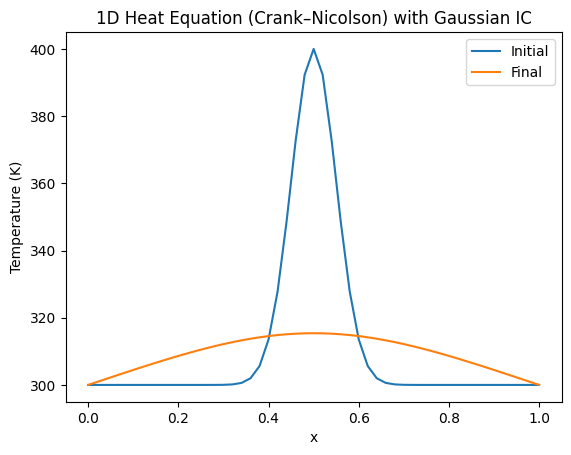

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def thomas_solve(a, b, c, d):
    """Thomas Algorithm to solve tridiagonal system A x = d."""
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i]   = b[i]   - w*c[i-1]
        d[i]   = d[i]   - w*d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

# -------------------------------
# Parameters
# -------------------------------
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 300.0
T_right= 300.0

# Gaussian initial condition
T = np.full(Nx, 300.0)
sigma = 0.05
peak_amplitude = 100.0  # so peak is 300 + 100 = 400
for i in range(Nx):
    T[i] += peak_amplitude * np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
plt.plot(x, time_history[0], label='Initial')
plt.plot(x, T, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()
